# SSM-1 — The linear state-space model

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/bdsaglam/bdsaglam.github.io/blob/main/courses/continual-learning/tracks/state-space-models/ssm1-linear-state-space.ipynb)

**The question:** how does a fixed linear recurrence become a long-range memory you can train in parallel?

Prerequisites: [M1](../../foundations/m1-associative-memory.ipynb), [M3](../../foundations/m3-linear-attention.ipynb), [M7](../../foundations/m7-three-dials.ipynb).

Linear attention collapsed the softmax sum into a running memory $\mathbf{S}_t=\mathbf{S}_{t-1}+\mathbf{v}_t\,\phi(\mathbf{k}_t)^\top$ that only ever adds. The master recurrence generalizes it with a gate $\alpha_t$ on the old state,

$$\mathbf{S}_t=\alpha_t\mathbf{S}_{t-1}+\beta_t\,(\text{write}_t)\,\phi(\mathbf{k}_t)^\top,$$

and linear attention is the setting with that gate held at $\alpha_t=1$: the memory never forgets (M7 §1–2). That memory also has no notion of a continuous process running underneath the tokens, and no decay rate you could tune, because it was built by removing an operation from attention rather than derived from a system that evolves in time.

This module derives a memory from the other direction. It starts from a continuous-time linear system $h'(t)=Ah(t)+Bx(t)$ driven by a matrix $A$, discretizes it into a recurrence whose per-step decay $\bar A$ is exactly M7's gate, and shows that recurrence is also a convolution you can run over the whole sequence at once. The one design choice that decides whether the memory reaches far back is the shape of $A$.

> Grounding: [S4](https://arxiv.org/abs/2111.00396) (Gu et al., 2021) §2 for the continuous system, the discretization, and the convolution kernel; [S4D](https://arxiv.org/abs/2206.11893) (Gu et al., 2022) §3 for the diagonal parameterization the toy runs and §4 for its initialization; [HiPPO](https://arxiv.org/abs/2008.07669) (Gu et al., 2020) for why a structured $A$ remembers. Equations are cited by section and number; anything I derive myself is marked as mine.


## Objective

After this module you should be able to:

- Write a continuous-time linear state-space model $h'(t)=Ah(t)+Bx(t)$, $y(t)=Ch(t)$ and read the state $h(t)$ as a running summary of the input's past.
- Discretize it with zero-order hold to the recurrence $h_t=\bar A h_{t-1}+\bar B x_t$, $y_t=Ch_t$, using $\bar A=\exp(\Delta A)$ and $\bar B=(\Delta A)^{-1}(\exp(\Delta A)-I)\,\Delta B$ (S4D §3.1).
- Unroll the recurrence into a convolution $y=\bar K * x$ with kernel $\bar K_\ell=C\bar A^\ell\bar B$ (S4 Eq. 5), and say which form trains and which infers.
- Explain why a structured diagonal $A$ keeps long-range history that a random one loses, with HiPPO's one-line reason (optimal projection of the past onto Legendre polynomials).
- State the module's dial setting: an additive write with the gate $\alpha_t=\bar A$ fixed and structured, against linear attention's $\alpha_t=1$.


## Why it exists (the limitation it opens up)

Linear attention reached a fixed-size memory by deleting the softmax, and it left the gate at $\alpha_t=1$: every token is added and nothing is removed (M7 §2, the gate dial). Two blind spots follow. The memory cannot forget, so old associations sit in the state at full strength until they saturate it. And it has no dial for *how fast* to forget, because it was never derived from a process that runs in time. Linear attention is a rule for accumulating tokens; it does not assume the tokens are samples of anything.

State-space models start from the opposite assumption. They posit a continuous linear system underneath the sequence, a differential equation whose state $h(t)$ integrates the input, and read the tokens as samples of it. Forgetting is then not bolted on: it falls out of the system's own dynamics, set by the matrix $A$. Discretizing that system gives a recurrence that looks like linear attention's with one change that is the whole module: the old state is multiplied by a decay $\bar A$ before the new input is written in. That $\bar A$ is the master recurrence's gate $\alpha_t$, no longer pinned at 1 but fixed once by $A$ and the step size $\Delta$, and held constant across the sequence.

So the dial setting is: keep linear attention's additive write, and turn the gate from $\alpha_t=1$ to a fixed structured $\bar A$. The state here is a vector driven by a scalar input rather than a matrix driven by key–value pairs, so there is no outer product in the toy, but the dial is the same one, what multiplies the old state before the new write. The reward is that the same recurrence has a convolution form you can train in parallel over the whole sequence. The bill the rest of the track pays is that a fixed $\bar A$ cannot decide what to remember from the content of a token; that is what selectivity fixes.

### Reading

- [S4](https://arxiv.org/abs/2111.00396) (Gu et al., 2021): §2 — the continuous SSM (Eq. 1), the discretization (Eq. 3), the convolution view and kernel (Eqs. 4–5). The grounding source for the recurrence-to-convolution identity. S4's own default discretization is the bilinear rule; the ZOH form below is S4D's.
- [S4D](https://arxiv.org/abs/2206.11893) (Gu et al., 2022): §3.1 — the ZOH discretization $\bar A=\exp(\Delta A)$, $\bar B=(\Delta A)^{-1}(\exp(\Delta A)-I)\,\Delta B$; §3.2 (Eq. 7) — the diagonal kernel $\bar K_\ell=\sum_n C_n\bar A_n^\ell\bar B_n$; §4 (Eq. 9) — the S4D-Lin initialization the toy uses.
- [HiPPO](https://arxiv.org/abs/2008.07669) (Gu et al., 2020): the structured $A$ as the optimal operator for online projection of the input's history onto Legendre polynomials. Used in brief in §4; not derived here.


## 1. The continuous system

A state-space model is a linear ODE. A scalar input $x(t)$ drives an $N$-dimensional state $h(t)$, and a readout collapses the state to an output:

$$h'(t)=A\,h(t)+B\,x(t),\qquad y(t)=C\,h(t).$$

$A\in\mathbb{R}^{N\times N}$ is the state matrix, $B\in\mathbb{R}^{N\times1}$ writes the input into the state, $C\in\mathbb{R}^{1\times N}$ reads it out (S4 Eq. 1, which also carries a skip term $D\,x(t)$ we set to zero). Solve the ODE for a single input impulse at $t=0$ and the output is $y(t)=C\,e^{tA}B$, where $e^{tA}$ is the matrix exponential, the operator that advances the linear system by time $t$. So the state is a fading trace of everything the input has done, and $A$ alone decides the shape of that fade.

Diagonalize $A$ and the picture is simplest: each diagonal entry $a=\mathrm{Re}(a)+i\,\mathrm{Im}(a)$ is one independent mode with response $e^{ta}$. Its real part sets how fast the mode decays, which is how long it remembers, and its imaginary part sets how fast it oscillates. Diagonalizing a real system produces complex conjugate modes, so from here $A$ (and with it $\bar A,\bar B,C$) is a vector of complex numbers and the output keeps only the real part; this is the diagonal S4D form the code uses. The cell integrates a three-mode system under a single impulse and plots the output.


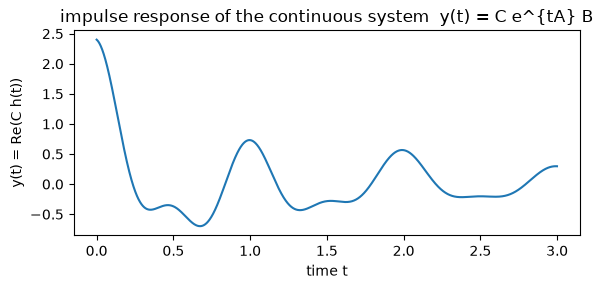

the state rings and decays: each mode of A adds a decaying oscillation to the output.
Re(a) sets how long a mode remembers; Im(a) sets its frequency.


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)

# three modes of a continuous linear system: a = Re + i*Im per channel.
# Re<0 sets the fade rate (how long the mode remembers); Im sets the frequency.
A_cont = torch.tensor([-0.5 + 6.2832j, -0.8 + 12.566j, -1.5 + 3.1416j], dtype=torch.cfloat)
B_cont = torch.ones(3, dtype=torch.cfloat)
C_cont = torch.tensor([1.0, 0.6, 0.8], dtype=torch.cfloat)

# integrate h'(t) = A h(t) + B x(t) with small Euler steps; a unit impulse enters at t=0.
T, steps = 3.0, 3000
tau = T / steps
h = torch.zeros(3, dtype=torch.cfloat)
ts, ys = [], []
for i in range(steps):
    x = (1.0 / tau) if i == 0 else 0.0        # unit impulse spread over one step
    h = h + tau * (A_cont * h + B_cont * x)   # one Euler step of the ODE
    ts.append(i * tau)
    ys.append((C_cont * h).sum().real.item())

plt.figure(figsize=(6, 3))
plt.plot(ts, ys)
plt.xlabel("time t"); plt.ylabel("y(t) = Re(C h(t))")
plt.title("impulse response of the continuous system  y(t) = C e^{tA} B")
plt.tight_layout(); plt.show()
print("the state rings and decays: each mode of A adds a decaying oscillation to the output.")
print("Re(a) sets how long a mode remembers; Im(a) sets its frequency.")

The impulse response is a sum of decaying oscillations, one per mode, exactly $C\,e^{tA}B$. Nothing about the input's past is stored except through the state, and the state is fully determined by $A$: change $A$ and you change how long the memory lasts and what it emphasizes. This is the object we want to feed discrete tokens, so the next step is to turn the continuous system into a step-by-step recurrence.


## 2. Discretize (ZOH) to a recurrence

Tokens arrive at discrete steps, so we need the state at times $t=0,\Delta,2\Delta,\dots$ rather than continuously. Zero-order hold makes the standard assumption that the input is constant across each step of width $\Delta$, then integrates the ODE *exactly* over that step. The result is a linear recurrence (S4D §3.1):

$$h_t=\bar A\,h_{t-1}+\bar B\,x_t,\qquad y_t=C\,h_t,\qquad \bar A=\exp(\Delta A),\quad \bar B=(\Delta A)^{-1}\big(\exp(\Delta A)-I\big)\,\Delta B.$$

Read $\bar A=\exp(\Delta A)$ as the exact one-step propagator of the continuous system, and $\bar B$ as the matching input weight that accounts for the input acting throughout the step. For a diagonal $A$ these become per-channel scalars: with mode $a_n$, reducing the S4D §3.1 formula to one channel (mine) gives

$$\bar A_n=\exp(\Delta a_n),\qquad \bar B_n=\frac{\exp(\Delta a_n)-1}{a_n}\,B_n.$$

The recurrence is now elementwise: $N$ independent scalar modes, each a leaky, oscillating accumulator of the input.

The gate is visible in $\bar A$. Linear attention's recurrence multiplied the old state by $1$; this one multiplies it by $\bar A=\exp(\Delta A)$, a fixed per-channel decay set by $A$ and $\Delta$. That is the dial turned. The cell discretizes a diagonal system and runs the recurrence on a random input.


In [2]:
def discretize(A, B, dt):
    # ZOH (S4D 3.1), diagonal case: Abar = exp(dt*A), Bbar = (exp(dt*A) - 1)/A * B
    Abar = torch.exp(dt * A)
    Bbar = (Abar - 1.0) / A * B
    return Abar, Bbar

def run_recurrence(Abar, Bbar, C, x):
    # h_t = Abar . h_{t-1} + Bbar . x_t ;  y_t = Re(C . h_t)   (elementwise, diagonal A)
    h = torch.zeros(Abar.shape[0], dtype=torch.cfloat)
    out = []
    for xt in x:
        h = Abar * h + Bbar * xt          # gate the old state by Abar, add the new input
        out.append((C * h).sum().real)    # readout; real part, since the signal is real
    return torch.stack(out)

torch.manual_seed(1)
N = 16
A = -0.5 + 1j * np.pi * torch.arange(N).to(torch.cfloat)   # a stable diagonal A (S4D-Lin, section 4)
B = torch.ones(N, dtype=torch.cfloat)
C = torch.randn(N, dtype=torch.cfloat)
dt = 1.0 / N
Abar, Bbar = discretize(A, B, dt)

L = 64
x = torch.randn(L)
y_rec = run_recurrence(Abar, Bbar, C, x)
print("state size N =", N, " sequence length L =", L)
print("|Abar| per mode (the per-channel gate) in [", f"{Abar.abs().min():.3f}", ",", f"{Abar.abs().max():.3f}", "]  -- all < 1, so the memory is stable")
print("first outputs y_rec[:4] =", [f"{v:.3f}" for v in y_rec[:4].tolist()])

state size N = 16  sequence length L = 64
|Abar| per mode (the per-channel gate) in [ 0.969 , 0.969 ]  -- all < 1, so the memory is stable
first outputs y_rec[:4] = ['-0.287', '-0.253', '0.031', '0.510']


Every mode has $|\bar A_n|<1$, so each one fades and the recurrence is stable; a mode with $|\bar A_n|\ge 1$ would blow up as the sequence runs. The step is cheap and sequential: one elementwise multiply-add per token, carrying a fixed-size state with no growing cache, which is the inference-time win linear attention also had. The next section shows the same recurrence has a second face that runs the whole sequence in parallel.


## 3. The recurrence is a convolution

Unroll the recurrence from $h_{-1}=0$. Each step multiplies the running state by $\bar A$ and adds $\bar B x_t$, so after $t$ steps

$$h_t=\sum_{\ell=0}^{t}\bar A^{\,\ell}\,\bar B\,x_{t-\ell},\qquad y_t=C\,h_t=\sum_{\ell=0}^{t}\big(C\,\bar A^{\,\ell}\,\bar B\big)\,x_{t-\ell}.$$

The bracket depends only on the lag $\ell$, not on $t$, so the whole output is a convolution of the input with a single fixed kernel (S4 Eqs. 4–5):

$$y=\bar K * x,\qquad \bar K=\big(C\bar B,\ C\bar A\bar B,\ C\bar A^{2}\bar B,\dots\big),\qquad \bar K_\ell=C\,\bar A^{\,\ell}\,\bar B.$$

For a diagonal $A$ the kernel is a sum over modes, $\bar K_\ell=\sum_n C_n\bar A_n^{\,\ell}\bar B_n$ (S4D Eq. 7). This is the same parallel-versus-recurrent duality as linear attention, in a new guise. During training the whole sequence is known, so you build $\bar K$ once and convolve, which parallelizes across all positions and runs by FFT in $O(L\log L)$. During inference you generate one token at a time, so you carry the state and step the recurrence at $O(1)$ per token. Two schedules, one function. The cell builds the kernel, convolves, and checks it against the step-by-step recurrence from §2. Equality is exact up to floating point, so it is an assertion, not a plot.


In [3]:
def ssm_kernel(Abar, Bbar, C, L):
    # Kbar_ell = sum_n C_n Abar_n^ell Bbar_n  (S4D Eq. 7); real part for a real output.
    ell = torch.arange(L)
    powers = Abar[None, :] ** ell[:, None]                 # (L, N): Abar_n^ell, a Vandermonde matrix
    return (powers * (Bbar * C)[None, :]).sum(-1).real     # (L,)

def conv1d_causal(K, x):
    # y_t = sum_{l=0}^{t} K_l x_{t-l}
    L = x.shape[0]
    y = torch.zeros(L)
    for t in range(L):
        m = min(t + 1, K.shape[0])
        y[t] = (K[:m] * x[t - torch.arange(m)]).sum()
    return y

K = ssm_kernel(Abar, Bbar, C, L)
y_conv = conv1d_causal(K, x)

print("recurrence output vs convolution output:")
print("  max |y_rec - y_conv| =", f"{(y_rec - y_conv).abs().max().item():.2e}")
assert torch.allclose(y_rec, y_conv, atol=1e-4)
print("  torch.allclose -> True: the two forms compute the identical function.")
print("train as a convolution over the whole sequence; infer as a step-by-step recurrence.")

recurrence output vs convolution output:
  max |y_rec - y_conv| = 9.54e-07
  torch.allclose -> True: the two forms compute the identical function.
train as a convolution over the whole sequence; infer as a step-by-step recurrence.


The two outputs match to floating-point tolerance because they are the same sum grouped two ways, exactly as linear attention's parallel and recurrent forms were. The kernel form is what makes an SSM trainable at scale: unlike a nonlinear RNN, whose per-step dependence blocks parallelism, the linear recurrence unrolls into one convolution and trains across all positions at once. This identity is the cheap part. S4's real work is computing $\bar K$ efficiently for a structured $A$, which the diagonal case in the next section reduces to a one-line Vandermonde product.


::: {.callout-note collapse="true"}
## Q: If the two forms compute the same function, why keep both?

Because they cost differently, and training and inference have opposite shapes.

- **Training** sees the whole sequence at once. The convolution builds one kernel $\bar K$ and applies it to every position in parallel, by FFT in $O(L\log L)$, saturating a GPU with no step-by-step dependency to wait on. This is the form you differentiate through.
- **Inference** generates one token at a time. The recurrence carries the fixed-size state $h_t$ and does one elementwise update per token, $O(1)$ time and memory per step, with no cache that grows in the sequence length.

So you train as a convolution and decode as a recurrence, the same weights computing the same function on two schedules. This is linear attention's parallel-versus-recurrent duality again, and it is the property the whole linear-time family is built on.

The catch, and the reason there is a track after this module: the convolution exists only because $\bar A,\bar B,C$ are the *same* at every step, which makes the kernel depend on the lag $\ell$ alone. The moment those parameters depend on the input, as they will under selectivity, the single global kernel is gone and the parallel form has to be recovered a different way, by a parallel scan (the [parallel-scan aside](ssm2-aside-parallel-scan.ipynb)).
:::


## 4. Why a structured $A$ remembers

The kernel is a sum of modes,

$$\bar K_\ell=\sum_n C_n\bar A_n^{\,\ell}\bar B_n,\qquad \bar A_n^{\,\ell}=e^{\Delta\ell\,\mathrm{Re}(a_n)}\,e^{i\Delta\ell\,\mathrm{Im}(a_n)}.$$

So the state is only ever as good a memory as this bank of modes allows. Pick $A$ at random and the modes scatter: some decay rates are so large that those modes are dead within a few steps, so their share of the history is gone, and the survivors cover the frequency axis unevenly. A fixed-size state built from a scattered bank cannot faithfully represent a signal from far back.

HiPPO is the reason a *particular* $A$ avoids this. It frames memory as online function approximation: at each moment, compress the entire history of the input into the $N$-dimensional state so that the state is the best degree-$N$ reconstruction of the past. HiPPO derives the $A$ for which the state is the optimal projection of the history onto Legendre polynomials, and its scaled version, HiPPO-LegS, remembers all of history without a prior on the timescale, so it stays accurate whether the relevant signal was recent or long ago (HiPPO, abstract and §2). S4 puts that structured $A$ inside a trainable SSM; S4D then shows a diagonal $A$ recovers almost all of it, and gives a clean initialization, S4D-Lin (Eq. 9): $a_n=-\tfrac12+i\pi n$, a uniform decay of $-\tfrac12$ with evenly spaced frequencies. The toy keeps $A$ diagonal and compares this structured choice against a random stable one.

The test is a delay task. Fix $A$ and $B$, then solve in closed form for the readout $C$ whose kernel best matches a shifted impulse $\bar K\approx e_D$, which is the SSM's way of asking the state to reproduce the input from $D$ steps ago. A structured $A$ has the modes to represent that delay; a random one does not.


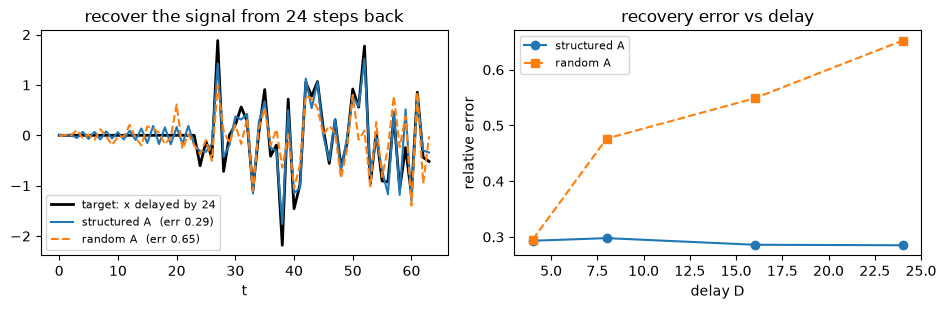

delays         : [4, 8, 16, 24]
structured err : ['0.293', '0.298', '0.286', '0.285']
random err     : ['0.295', '0.476', '0.549', '0.652']
structured A: error stays low and roughly flat -- history from far back survives in the fixed-size state.
random A: error climbs with the delay -- the older the signal, the more a scattered mode bank has dropped it.


In [4]:
def s4d_lin(N):
    # S4D-Lin initialization (S4D Eq. 9): Re = -1/2, evenly spaced imaginary parts.
    n = torch.arange(N)
    return -0.5 + 1j * np.pi * n.to(torch.cfloat)

def random_diag(N, seed):
    # a random but stable diagonal A: random fade rates (Re<0) and random frequencies.
    g = torch.Generator().manual_seed(seed)
    re = -torch.rand(N, generator=g) - 0.05
    im = (torch.rand(N, generator=g) * 2 - 1) * np.pi * (N - 1)
    return re + 1j * im

def fit_delay_readout(Abar, Bbar, L, D):
    # the kernel is linear in C; solve for the C whose real kernel best matches a delayed impulse e_D.
    ell = torch.arange(L)
    Psi = (Abar[None, :] ** ell[:, None]) * Bbar[None, :]      # (L, N), fixed by A and B
    M = torch.cat([Psi.real, -Psi.imag], dim=1)               # real kernel = M @ [Re C; Im C]
    target = torch.zeros(L); target[D] = 1.0
    C_ri = torch.linalg.lstsq(M, target).solution
    return M @ C_ri                                           # the fitted (real) kernel

N, L, dt = 16, 64, 1.0 / 16                                    # N modes, length L; state is a real compression
Abar_s, Bbar_s = discretize(s4d_lin(N),   torch.ones(N, dtype=torch.cfloat), dt)   # structured
Abar_r, Bbar_r = discretize(random_diag(N, 1), torch.ones(N, dtype=torch.cfloat), dt)   # random

xtest = torch.randn(L, generator=torch.Generator().manual_seed(101))
delays = [4, 8, 16, 24]
err_s, err_r = [], []
for D in delays:
    Ks = fit_delay_readout(Abar_s, Bbar_s, L, D)
    Kr = fit_delay_readout(Abar_r, Bbar_r, L, D)
    tgt = torch.zeros(L); tgt[D:] = xtest[:L - D]             # x delayed by D
    err_s.append(((conv1d_causal(Ks, xtest) - tgt).norm() / tgt.norm()).item())
    err_r.append(((conv1d_causal(Kr, xtest) - tgt).norm() / tgt.norm()).item())

D = 24
Ks = fit_delay_readout(Abar_s, Bbar_s, L, D)
Kr = fit_delay_readout(Abar_r, Bbar_r, L, D)
tgt = torch.zeros(L); tgt[D:] = xtest[:L - D]
y_struct, y_rand = conv1d_causal(Ks, xtest), conv1d_causal(Kr, xtest)

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.2))
ax[0].plot(tgt, "k", lw=2, label=f"target: x delayed by {D}")
ax[0].plot(y_struct, label=f"structured A  (err {err_s[-1]:.2f})")
ax[0].plot(y_rand, "--", label=f"random A  (err {err_r[-1]:.2f})")
ax[0].set_title(f"recover the signal from {D} steps back"); ax[0].set_xlabel("t"); ax[0].legend(fontsize=8)
ax[1].plot(delays, err_s, "o-", label="structured A")
ax[1].plot(delays, err_r, "s--", label="random A")
ax[1].set_title("recovery error vs delay"); ax[1].set_xlabel("delay D"); ax[1].set_ylabel("relative error"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("delays         :", delays)
print("structured err :", [f"{e:.3f}" for e in err_s])
print("random err     :", [f"{e:.3f}" for e in err_r])
print("structured A: error stays low and roughly flat -- history from far back survives in the fixed-size state.")
print("random A: error climbs with the delay -- the older the signal, the more a scattered mode bank has dropped it.")

The structured error is low and nearly flat as the delay grows, while the random one climbs: at a short lag the two are close, but by the longest delay the random state has lost most of the older signal and the structured state has not. That flatness is HiPPO's timescale robustness showing up directly, the state staying a good summary whether the signal it must recover is recent or old. Both models have the same state size, the same $B$, and the same fitted readout procedure; the only thing that differs is the shape of $A$, which is the point.

**Scope.** This toy is a diagonal S4D model, not the full HiPPO operator: the structured $A$ is S4D-Lin's evenly spaced diagonal (Eq. 9), which recovers most of S4 while skipping the HiPPO derivation that justifies it. The input is a single scalar channel and the sequences are short (length 64, state size 16), so the memory under test is small. And $C$ is fit in closed form to a fixed delay, which isolates whether the state *can* represent that delay rather than training the model end to end or standing in for a real task. Because $C$ enters the kernel linearly, the closed-form fit is the optimal readout for each $A$, so the comparison judges both at their best. What it does settle is the one thing this section is about: with the state size held fixed, the shape of $A$ decides whether a signal from far back is still in the state or already gone.


::: {.callout-note collapse="true"}
## Q: Why does the toy use a complex $A$? Can a real diagonal remember?

A real diagonal $A$ gives modes $e^{-\lambda_n\ell}$ that only decay, each largest at lag $\ell=0$ and shrinking from there. A sum of them can form a fading average of recent inputs, but it can never place a bump at a lag $D>0$, which is what a delay line needs. The delay in this section needs oscillation, and oscillation is the imaginary part of $a_n$: the mode $e^{i\Delta\ell\,\mathrm{Im}(a_n)}$ contributes a wave at frequency $\Delta\,\mathrm{Im}(a_n)$, and a sum of waves at evenly spaced frequencies can build a shifted impulse the way a Fourier series does.

This is why S4 and S4D use complex diagonal $A$, in conjugate pairs so the output stays real (S4D §3). The toy takes the real part of a complex readout, which is the same thing as one real linear functional of the state, and keeps the code to one line. The takeaway is that a structured $A$ remembers not because it decays slowly but because its modes tile the frequency axis, giving the fixed-size state a basis rich enough to reconstruct the past.
:::


## Exit check

Ready for SSM-2 when you can:

1. Write the continuous SSM $h'(t)=Ah(t)+Bx(t)$, $y=Ch(t)$, and say why its impulse response $Ce^{tA}B$ makes the state a fading summary of the input's past.
2. Discretize with ZOH to $h_t=\bar A h_{t-1}+\bar B x_t$, and write $\bar A=\exp(\Delta A)$ and $\bar B=(\Delta A)^{-1}(\exp(\Delta A)-I)\Delta B$, plus the per-channel diagonal form.
3. Unroll the recurrence into the convolution $y=\bar K*x$ with $\bar K_\ell=C\bar A^\ell\bar B$, and say which form trains, which infers, and why they compute the same function.
4. Explain why a structured diagonal $A$ (S4D-Lin) keeps long-range history where a random one loses it, and give HiPPO's one-line reason.
5. State the dial setting: an additive write with the gate $\alpha_t=\bar A$ fixed and structured, against linear attention's $\alpha_t=1$, and say what a fixed $\bar A$ still cannot do.

**Next →** [SSM-2 — Selectivity](ssm2-selectivity.ipynb). A fixed $\bar A$ applies the same decay to every token, so the memory cannot spend more of itself on a token that matters and less on filler. Selectivity makes $\Delta$, $B$, and $C$ depend on the input, which turns the gate from fixed-structured to input-dependent, and pays for it by giving up the single global convolution this module relied on.
